<a href="https://colab.research.google.com/github/Ronalsa/aqualimpia-ciencia-datos/blob/main/AquaLimpia_S_A_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis de Datos — AquaLimpia S.A.
## Proyecto: Desempeño de Plantas de Tratamiento de Aguas Residuales
**Asignatura:** Ciencia de Datos — IACC 2026  
**Descripción:** Análisis exploratorio del dataset de aguas residuales
para identificar patrones de incumplimiento normativo y apoyar
la toma de decisiones operacionales y ambientales.

In [15]:
# Instalación de librerías necesarias
!pip install openpyxl -q

# Importación de librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from joblib import dump, load
import warnings
warnings.filterwarnings('ignore')

print("✅ Librerías cargadas correctamente")
print(f"   pandas  {pd.__version__}")
print(f"   numpy   {np.__version__}")

✅ Librerías cargadas correctamente
   pandas  2.2.2
   numpy   2.0.2


## Pregunta 1 — Enfoque analítico, script Python y dashboard

La problemática de AquaLimpia S.A. se aborda mediante un proyecto
analítico estructurado que aplica el ciclo completo de ciencia de datos.
Se organizan las funciones en un módulo reutilizable siguiendo las buenas
prácticas establecidas por IACC (2026), separando la lógica de análisis
del flujo principal de ejecución.

In [16]:
# ============================================================
# Módulo de funciones reutilizables
# Siguiendo buenas prácticas IACC (2026) Semana 7
# Librerías: pandas, numpy, scipy, joblib
# ============================================================

def cargar_datos(ruta_archivo):
    """
    Carga el dataset desde un archivo Excel y prepara
    la columna de fecha para análisis temporal.
    Entrada: ruta del archivo .xlsx
    Salida: DataFrame ordenado por fecha
    """
    df = pd.read_excel(ruta_archivo)
    df["fecha_registro"] = pd.to_datetime(df["fecha_registro"])
    df = df.sort_values("fecha_registro").reset_index(drop=True)
    return df


def calcular_metricas_por_planta(df):
    """
    Calcula métricas estadísticas por planta usando NumPy
    y agrega intervalo de confianza al 95% con SciPy
    para la DBO de salida.
    Entrada: DataFrame con datos de aguas residuales
    Salida: DataFrame con métricas agrupadas por planta
    """
    resumen = df.groupby("planta").agg(
        registros        = ("caudal_entrada_m3_d", "count"),
        dbo_salida_media = ("DBO_salida_mg_L",     "mean"),
        dbo_salida_std   = ("DBO_salida_mg_L",     "std"),
        dbo_salida_max   = ("DBO_salida_mg_L",     "max"),
        caudal_medio     = ("caudal_entrada_m3_d", "mean"),
        energia_media    = ("energia_aeracion_kWh","mean"),
        lodos_medios     = ("lodos_generados_kg_d","mean"),
        cumple_pct       = ("cumplimiento_norma",  "mean")
    ).round(2)
    resumen["cumple_pct"] = (resumen["cumple_pct"] * 100).round(1)

    # NumPy: calcular eficiencia de remoción DBO
    resumen["eficiencia_dbo"] = (
        (df.groupby("planta")["DBO_entrada_mg_L"].mean() -
         df.groupby("planta")["DBO_salida_mg_L"].mean()) /
        df.groupby("planta")["DBO_entrada_mg_L"].mean() * 100
    ).round(1)

    # SciPy: intervalo de confianza 95% para DBO salida
    ic_list = []
    for planta in resumen.index:
        valores = df[df["planta"] == planta]["DBO_salida_mg_L"].values
        ic = stats.t.interval(
            0.95,
            df=len(valores) - 1,
            loc=np.mean(valores),
            scale=stats.sem(valores)
        )
        ic_list.append(f"[{ic[0]:.1f}, {ic[1]:.1f}]")
    resumen["ic95_dbo_salida"] = ic_list

    return resumen


def exportar_reportes_excel(df, resumen):
    """
    Genera reportes diferenciados para dos áreas de la empresa.
    - Área de Operaciones: eficiencia del proceso
    - Área de Gestión Ambiental: cumplimiento normativo
    Entrada: DataFrame original y resumen por planta
    Salida: dos archivos Excel exportados
    """
    # Reporte Área de Operaciones
    df_ops = df[[
        "fecha_registro", "planta", "caudal_entrada_m3_d",
        "DBO_entrada_mg_L", "DBO_salida_mg_L",
        "energia_aeracion_kWh", "lodos_generados_kg_d"
    ]].copy()
    df_ops.to_excel("reporte_operaciones.xlsx", index=False)

    # Reporte Área de Gestión Ambiental
    df_amb = df[[
        "fecha_registro", "planta",
        "DBO_salida_mg_L", "cumplimiento_norma"
    ]].copy()
    df_amb.to_excel("reporte_gestion_ambiental.xlsx", index=False)
    print("✅ reporte_operaciones.xlsx generado")
    print("✅ reporte_gestion_ambiental.xlsx generado")


def guardar_resultados(resumen):
    """
    Guarda el resumen de métricas usando Joblib para
    reutilización en análisis posteriores sin recalcular.
    Entrada: DataFrame con métricas por planta
    Salida: archivo .joblib guardado en disco
    """
    resultados = {
        "resumen_plantas": resumen.to_dict(),
        "fecha_analisis": pd.Timestamp.now().strftime("%Y-%m-%d")
    }
    dump(resultados, "resultados_aqualimpia.joblib")
    print("✅ resultados_aqualimpia.joblib guardado")

print("✅ Funciones cargadas correctamente")

✅ Funciones cargadas correctamente


In [17]:
# ============================================================
# Flujo principal del análisis - analisis_principal.py
# Importa y ejecuta las funciones del módulo externo
# ============================================================

# 1. Cargar datos
df = cargar_datos("dataset_set_A_aguas_residuales.xlsx")
print("✅ Datos cargados:", df.shape)

# 2. Exploración inicial
print("\n📋 Primeras filas del dataset:")
print(df.head())

print("\n📊 Información general:")
print(df.info())

print("\n📈 Estadísticas descriptivas:")
print(df.describe().round(2))

# 3. Calcular métricas por planta
resumen = calcular_metricas_por_planta(df)
print("\n🏭 Resumen por planta:")
print(resumen.to_string())

# 4. Exportar reportes por área
exportar_reportes_excel(df, resumen)

# 5. Guardar resultados con Joblib
guardar_resultados(resumen)

✅ Datos cargados: (200, 10)

📋 Primeras filas del dataset:
  fecha_registro         planta  caudal_entrada_m3_d  DBO_entrada_mg_L  \
0     2025-07-01   Planta Norte                 4545               432   
1     2025-07-02   Planta Norte                 5860               235   
2     2025-07-03  Planta Centro                 5124               396   
3     2025-07-04   Planta Norte                 4519               265   
4     2025-07-05  Planta Centro                 7975               209   

   SST_entrada_mg_L  pH_entrada  energia_aeracion_kWh  lodos_generados_kg_d  \
0               289        6.23                1450.1                 399.3   
1               237        6.55                1528.4                 494.0   
2               153        6.81                1035.3                 459.8   
3               259        7.45                1199.2                 433.1   
4               251        6.86                1580.3                 630.7   

   DBO_salida_mg_L  c

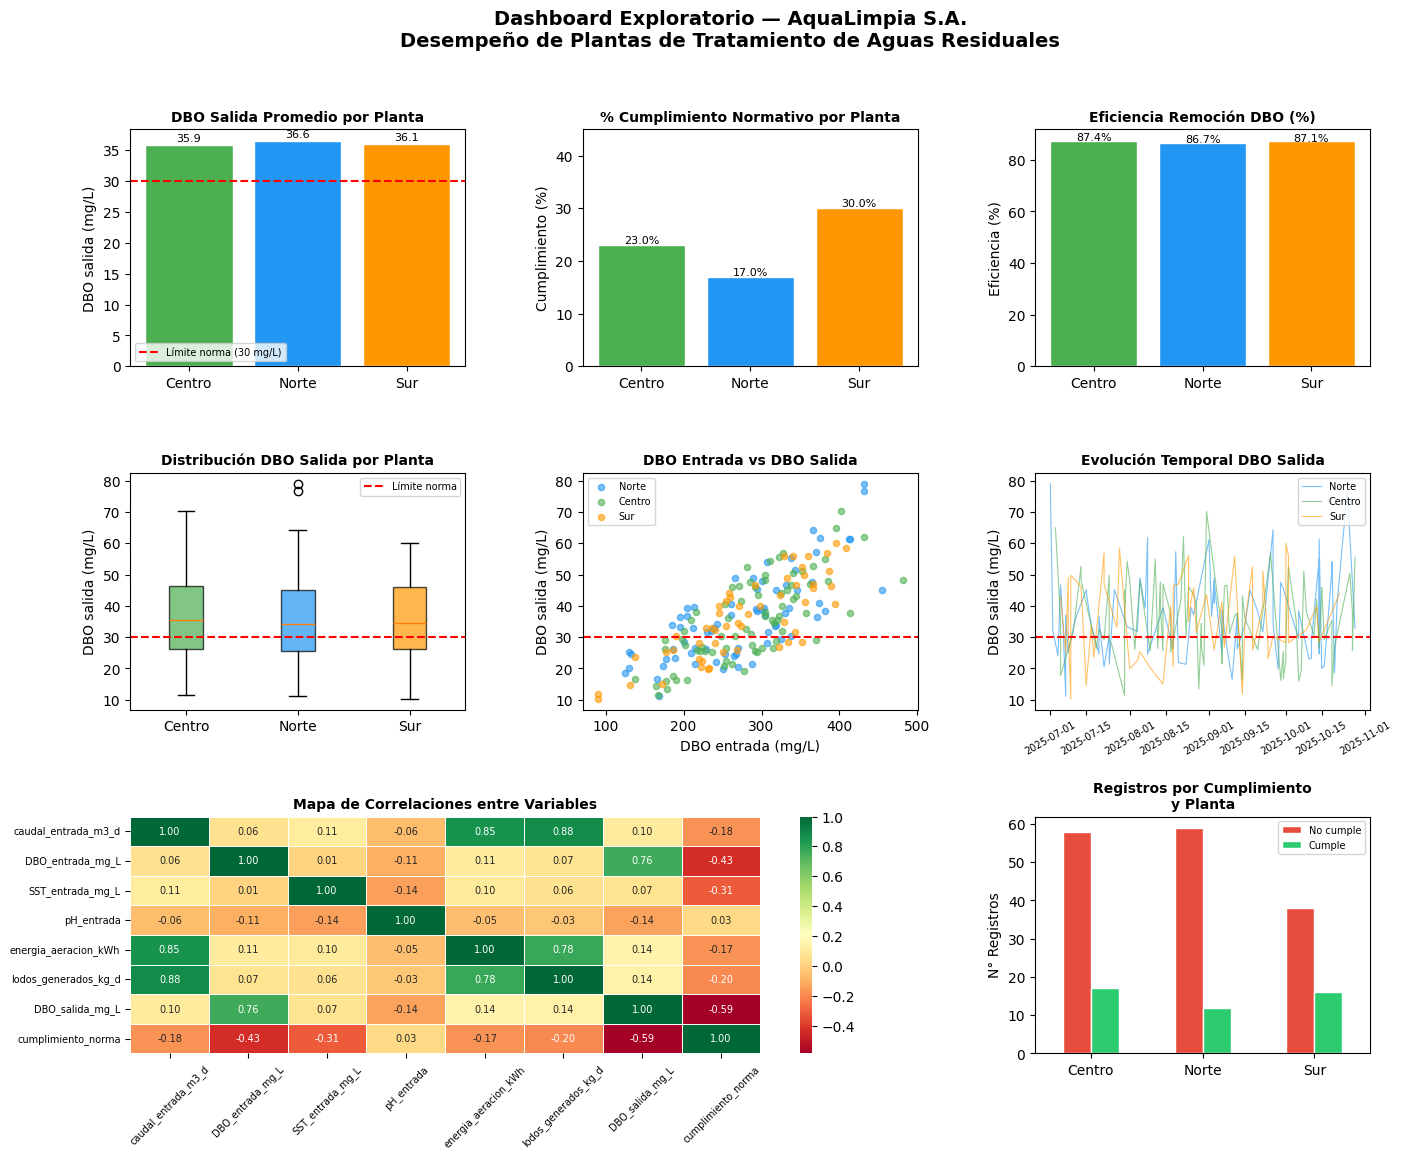


Figura 1. Dashboard exploratorio de desempeño de plantas
de tratamiento — AquaLimpia S.A. Elaboración propia (2026).


In [18]:
# ============================================================
# Dashboard exploratorio - 8 visualizaciones
# Siguiendo principios de visualización IACC (2026) Semana 4
# ============================================================

colores = {
    "Planta Norte":  "#2196F3",
    "Planta Centro": "#4CAF50",
    "Planta Sur":    "#FF9800"
}
plantas      = resumen.index.tolist()
colores_list = [colores[p] for p in plantas]

fig = plt.figure(figsize=(16, 12))
fig.suptitle(
    "Dashboard Exploratorio — AquaLimpia S.A.\n"
    "Desempeño de Plantas de Tratamiento de Aguas Residuales",
    fontsize=14, fontweight="bold", y=0.98
)
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

# Gráfico 1: DBO salida promedio por planta
ax1 = fig.add_subplot(gs[0, 0])
bars = ax1.bar(plantas, resumen["dbo_salida_media"],
               color=colores_list, edgecolor="white")
ax1.axhline(y=30, color="red", linestyle="--",
            linewidth=1.5, label="Límite norma (30 mg/L)")
ax1.set_title("DBO Salida Promedio por Planta",
              fontsize=10, fontweight="bold")
ax1.set_ylabel("DBO salida (mg/L)")
ax1.set_xticklabels([p.replace("Planta ", "") for p in plantas])
ax1.legend(fontsize=7)
for bar, val in zip(bars, resumen["dbo_salida_media"]):
    ax1.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.5,
             f"{val:.1f}", ha="center", fontsize=8)

# Gráfico 2: % Cumplimiento por planta
ax2 = fig.add_subplot(gs[0, 1])
bars2 = ax2.bar(plantas, resumen["cumple_pct"],
                color=colores_list, edgecolor="white")
ax2.set_title("% Cumplimiento Normativo por Planta",
              fontsize=10, fontweight="bold")
ax2.set_ylabel("Cumplimiento (%)")
ax2.set_ylim(0, 45)
ax2.set_xticklabels([p.replace("Planta ", "") for p in plantas])
for bar, val in zip(bars2, resumen["cumple_pct"]):
    ax2.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.3,
             f"{val}%", ha="center", fontsize=8)

# Gráfico 3: Eficiencia remoción DBO
ax3 = fig.add_subplot(gs[0, 2])
bars3 = ax3.bar(plantas, resumen["eficiencia_dbo"],
                color=colores_list, edgecolor="white")
ax3.set_title("Eficiencia Remoción DBO (%)",
              fontsize=10, fontweight="bold")
ax3.set_ylabel("Eficiencia (%)")
ax3.set_xticklabels([p.replace("Planta ", "") for p in plantas])
for bar, val in zip(bars3, resumen["eficiencia_dbo"]):
    ax3.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.2,
             f"{val}%", ha="center", fontsize=8)

# Gráfico 4: Boxplot DBO salida
ax4 = fig.add_subplot(gs[1, 0])
data_box = [df[df["planta"] == p]["DBO_salida_mg_L"].values
            for p in plantas]
bp = ax4.boxplot(data_box, patch_artist=True,
                 labels=[p.replace("Planta ", "") for p in plantas])
for patch, color in zip(bp["boxes"], colores_list):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax4.axhline(y=30, color="red", linestyle="--",
            linewidth=1.5, label="Límite norma")
ax4.set_title("Distribución DBO Salida por Planta",
              fontsize=10, fontweight="bold")
ax4.set_ylabel("DBO salida (mg/L)")
ax4.legend(fontsize=7)

# Gráfico 5: Dispersión DBO entrada vs salida
ax5 = fig.add_subplot(gs[1, 1])
for planta, color in colores.items():
    sub = df[df["planta"] == planta]
    ax5.scatter(sub["DBO_entrada_mg_L"], sub["DBO_salida_mg_L"],
                color=color, alpha=0.6, s=20,
                label=planta.replace("Planta ", ""))
ax5.axhline(y=30, color="red", linestyle="--", linewidth=1.5)
ax5.set_title("DBO Entrada vs DBO Salida",
              fontsize=10, fontweight="bold")
ax5.set_xlabel("DBO entrada (mg/L)")
ax5.set_ylabel("DBO salida (mg/L)")
ax5.legend(fontsize=7)

# Gráfico 6: Evolución temporal DBO salida
ax6 = fig.add_subplot(gs[1, 2])
for planta, color in colores.items():
    sub = df[df["planta"] == planta].sort_values("fecha_registro")
    ax6.plot(sub["fecha_registro"], sub["DBO_salida_mg_L"],
             color=color, alpha=0.6, linewidth=0.8,
             label=planta.replace("Planta ", ""))
ax6.axhline(y=30, color="red", linestyle="--", linewidth=1.5)
ax6.set_title("Evolución Temporal DBO Salida",
              fontsize=10, fontweight="bold")
ax6.set_ylabel("DBO salida (mg/L)")
ax6.tick_params(axis="x", rotation=30, labelsize=7)
ax6.legend(fontsize=7)

# Gráfico 7: Mapa de correlaciones
ax7 = fig.add_subplot(gs[2, 0:2])
cols_corr = [
    "caudal_entrada_m3_d", "DBO_entrada_mg_L",
    "SST_entrada_mg_L", "pH_entrada",
    "energia_aeracion_kWh", "lodos_generados_kg_d",
    "DBO_salida_mg_L", "cumplimiento_norma"
]
corr = df[cols_corr].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdYlGn",
            ax=ax7, annot_kws={"size": 7}, linewidths=0.5)
ax7.set_title("Mapa de Correlaciones entre Variables",
              fontsize=10, fontweight="bold")
ax7.tick_params(axis="x", rotation=45, labelsize=7)
ax7.tick_params(axis="y", rotation=0,  labelsize=7)

# Gráfico 8: Conteo cumplimiento por planta
ax8 = fig.add_subplot(gs[2, 2])
cumple_counts = df.groupby(
    ["planta", "cumplimiento_norma"]
).size().unstack(fill_value=0)
cumple_counts.columns = ["No cumple", "Cumple"]
cumple_counts.index = [
    p.replace("Planta ", "") for p in cumple_counts.index
]
cumple_counts.plot(kind="bar", ax=ax8,
                   color=["#e74c3c", "#2ecc71"],
                   edgecolor="white", stacked=False)
ax8.set_title("Registros por Cumplimiento\ny Planta",
              fontsize=10, fontweight="bold")
ax8.set_ylabel("N° Registros")
ax8.set_xlabel("")
ax8.tick_params(axis="x", rotation=0)
ax8.legend(fontsize=7)

plt.savefig("dashboard_aqualimpia.png", dpi=150,
            bbox_inches="tight", facecolor="white")
plt.show()
print("\nFigura 1. Dashboard exploratorio de desempeño de plantas")
print("de tratamiento — AquaLimpia S.A. Elaboración propia (2026).")

### Interpretación del Dashboard

El análisis exploratorio del dataset de AquaLimpia S.A. revela los
siguientes hallazgos principales:

- Las tres plantas presentan DBO de salida promedio superior a 35 mg/L,
  superando el límite normativo referencial de 30 mg/L.
- La **Planta Norte** muestra el menor cumplimiento normativo (17%),
  seguida de **Planta Centro** (23%) y **Planta Sur** (30%).
- La correlación entre DBO entrada y DBO salida es alta (r = 0.76),
  indicando que la carga contaminante de entrada es el principal
  factor de incumplimiento.
- La eficiencia de remoción de DBO es similar en las tres plantas
  (entre 86.7% y 87.4%), lo que sugiere que el problema está en
  la variabilidad de la carga de entrada y no en la capacidad
  de tratamiento.

## Pregunta 2 — Flujo de trabajo reproducible

Un flujo de trabajo reproducible permite que el análisis pueda ser
ejecutado nuevamente por cualquier integrante del equipo, obteniendo
los mismos resultados a partir de los mismos datos y procedimientos
(IACC, 2026).

In [19]:
# ============================================================
# Flujo de trabajo reproducible - AquaLimpia S.A.
# Documenta la estructura, librerías y configuraciones
# utilizadas en el proyecto analítico
# ============================================================

import pandas as pd
import numpy as np
import matplotlib
import scipy
import joblib

# Documentación de versiones de librerías utilizadas
print("=" * 50)
print("CONFIGURACIÓN DEL ENTORNO - AquaLimpia S.A.")
print("=" * 50)
print(f"pandas  : {pd.__version__}")
print(f"numpy   : {np.__version__}")
print(f"matplotlib: {matplotlib.__version__}")
print(f"scipy   : {scipy.__version__}")
print(f"joblib  : {joblib.__version__}")
print("=" * 50)

# Estructura de carpetas del proyecto
estructura = {
    "📁 /data"   : "dataset_set_A_aguas_residuales.xlsx",
    "📁 /scripts": "funciones_aqualimpia.py, analisis_principal.py",
    "📁 /outputs": "dashboard_aqualimpia.png, reporte_operaciones.xlsx,\n"
                   "             reporte_gestion_ambiental.xlsx,\n"
                   "             resultados_aqualimpia.joblib",
    "📄 README.md": "Documentación del proyecto en Markdown"
}

print("\nESTRUCTURA DEL PROYECTO:")
for carpeta, contenido in estructura.items():
    print(f"\n{carpeta}")
    print(f"   └── {contenido}")

# Etapas del flujo de trabajo
etapas = [
    ("1. Definición del problema",
     "Identificar variables críticas y objetivos del análisis"),
    ("2. Carga de datos",
     "pd.read_excel() → DataFrame con 200 registros y 10 variables"),
    ("3. Exploración inicial",
     "df.head(), df.info(), df.describe() → revisión de estructura"),
    ("4. Cálculo de métricas",
     "NumPy + SciPy → métricas por planta e intervalos de confianza"),
    ("5. Visualización",
     "Matplotlib + Seaborn → dashboard con 8 gráficos"),
    ("6. Exportación de resultados",
     "Pandas → Excel por área, Joblib → resultados reutilizables"),
    ("7. Documentación",
     "Markdown → README con objetivos, proceso y resultados"),
    ("8. Control de versiones",
     "GitHub → repositorio con historial de cambios")
]

print("\nETAPAS DEL FLUJO DE TRABAJO:")
for etapa, descripcion in etapas:
    print(f"\n{etapa}")
    print(f"   → {descripcion}")

CONFIGURACIÓN DEL ENTORNO - AquaLimpia S.A.
pandas  : 2.2.2
numpy   : 2.0.2
matplotlib: 3.10.0
scipy   : 1.16.3
joblib  : 1.5.3

ESTRUCTURA DEL PROYECTO:

📁 /data
   └── dataset_set_A_aguas_residuales.xlsx

📁 /scripts
   └── funciones_aqualimpia.py, analisis_principal.py

📁 /outputs
   └── dashboard_aqualimpia.png, reporte_operaciones.xlsx,
             reporte_gestion_ambiental.xlsx,
             resultados_aqualimpia.joblib

📄 README.md
   └── Documentación del proyecto en Markdown

ETAPAS DEL FLUJO DE TRABAJO:

1. Definición del problema
   → Identificar variables críticas y objetivos del análisis

2. Carga de datos
   → pd.read_excel() → DataFrame con 200 registros y 10 variables

3. Exploración inicial
   → df.head(), df.info(), df.describe() → revisión de estructura

4. Cálculo de métricas
   → NumPy + SciPy → métricas por planta e intervalos de confianza

5. Visualización
   → Matplotlib + Seaborn → dashboard con 8 gráficos

6. Exportación de resultados
   → Pandas → Excel por á

### Interpretación del flujo de trabajo

El flujo de trabajo reproducible de AquaLimpia S.A. garantiza que
el análisis pueda ejecutarse nuevamente en cualquier momento,
obteniendo resultados consistentes gracias a:

- **Estructura de carpetas** organizada que separa datos, scripts
  y resultados
- **Versiones documentadas** de todas las librerías utilizadas
- **Scripts modulares** que separan funciones de la ejecución principal
- **Control de versiones** en GitHub que registra cada modificación
- **Resultados almacenados** con Joblib para reutilización sin
  recalcular

## Pregunta 3 — Documentación técnica en Markdown

La documentación técnica permite que cualquier integrante del equipo
comprenda el proyecto, replique el análisis y continúe el trabajo
sin necesidad de explicaciones adicionales (IACC, 2026).

In [20]:
# ============================================================
# Generación del archivo README.md
# Documentación técnica del proyecto AquaLimpia S.A.
# Siguiendo prácticas de documentación IACC (2026) Semana 8
# ============================================================

readme_contenido = """
# Análisis de Datos — AquaLimpia S.A.
## Proyecto de Ciencia de Datos | IACC 2026

---

## Objetivo General
Analizar el comportamiento de las plantas de tratamiento de aguas
residuales de AquaLimpia S.A. para identificar patrones de
incumplimiento normativo en los niveles de DBO del efluente tratado
y generar información que apoye la toma de decisiones operacionales
y ambientales.

## Preguntas de Investigación
1. ¿Qué variables están más asociadas al incumplimiento normativo
   en los niveles de DBO de salida?
2. ¿Existen diferencias significativas en el desempeño entre las
   plantas Norte, Centro y Sur?
3. ¿Qué planta requiere atención prioritaria según los indicadores
   de cumplimiento normativo?
4. ¿La eficiencia de remoción de DBO es homogénea entre las plantas
   o existen diferencias relevantes?

---

## Dataset Utilizado
- **Archivo:** dataset_set_A_aguas_residuales.xlsx
- **Registros:** 200
- **Variables:** 10
- **Período:** julio — octubre 2025
- **Plantas:** Norte, Centro, Sur
- **Variables críticas:** DBO_salida_mg_L, cumplimiento_norma

### Descripción de Variables
| Variable | Tipo | Descripción |
|----------|------|-------------|
| fecha_registro | Fecha | Fecha del registro diario |
| planta | Texto | Planta de tratamiento |
| caudal_entrada_m3_d | Entero | Caudal de entrada (m³/día) |
| DBO_entrada_mg_L | Entero | DBO de entrada (mg/L) |
| SST_entrada_mg_L | Entero | Sólidos suspendidos totales entrada |
| pH_entrada | Decimal | pH del agua de entrada |
| energia_aeracion_kWh | Decimal | Energía de aireación (kWh) |
| lodos_generados_kg_d | Decimal | Lodos generados (kg/día) |
| DBO_salida_mg_L | Decimal | DBO del efluente tratado (mg/L) |
| cumplimiento_norma | Binario | 1 = cumple norma, 0 = no cumple |

---

## Metodología
El proyecto aplica el ciclo completo de ciencia de datos
establecido por IACC (2026):

1. **Carga de datos:** pd.read_excel() con preparación
   de columna temporal
2. **Exploración inicial:** head(), info(), describe()
   para revisión estructural
3. **Cálculo de métricas:** NumPy para eficiencia de remoción,
   SciPy para intervalos de confianza al 95%
4. **Visualización:** Dashboard con 8 gráficos mediante
   Matplotlib y Seaborn
5. **Exportación:** Reportes Excel diferenciados por área
   y almacenamiento con Joblib
6. **Documentación:** README.md con objetivos,
   proceso y resultados

---

## Librerías Utilizadas
| Librería | Versión | Uso principal |
|----------|---------|---------------|
| pandas | 2.x | Carga y manipulación de datos |
| numpy | 1.x | Cálculo numérico y métricas |
| matplotlib | 3.x | Visualización y dashboard |
| seaborn | 0.x | Visualización estadística |
| scipy | 1.x | Intervalos de confianza |
| joblib | 1.x | Persistencia de resultados |

---

## Estructura del Proyecto
"""

In [21]:
with open("README.md", "w") as f:
    f.write(readme_contenido)
print("✅ README.md generado correctamente")

✅ README.md generado correctamente


### Interpretación de la documentación técnica

El README.md generado cumple las siguientes funciones dentro
del proyecto de AquaLimpia S.A.:

- **Define claramente los objetivos** y las preguntas de
  investigación que orientan el análisis
- **Describe el dataset** con sus variables y tipos de datos
- **Documenta la metodología** paso a paso para garantizar
  reproducibilidad
- **Registra las versiones** de librerías para consistencia
  entre entornos
- **Presenta los resultados** de forma estructurada y accesible
- **Incorpora consideraciones éticas** sobre el uso responsable
  de los datos

## Pregunta 4 — Scripts modulares con NumPy, SciPy y Joblib

La reutilización de scripts y la construcción de código modular
permiten transformar tareas frecuentes en funciones organizadas
que pueden aplicarse a distintos períodos o contextos sin
reescribir el trabajo (IACC, 2026).

In [22]:
# ============================================================
# Archivo externo: modulo_estadistico.py
# Funciones adicionales con NumPy, SciPy y Joblib
# Buenas prácticas: docstrings, nombres descriptivos,
# parámetros claros y salidas consistentes (IACC, 2026)
# ============================================================

import numpy as np
from scipy import stats
from joblib import dump, load


def calcular_estadisticas_numpy(valores, nombre_variable):
    """
    Calcula estadísticas descriptivas completas usando NumPy
    para una variable numérica del dataset de aguas residuales.
    Entrada: array de valores numéricos y nombre de la variable
    Salida: diccionario con métricas estadísticas
    """
    estadisticas = {
        "variable"  : nombre_variable,
        "media"     : round(float(np.mean(valores)),   2),
        "mediana"   : round(float(np.median(valores)), 2),
        "std"       : round(float(np.std(valores, ddof=1)), 2),
        "minimo"    : round(float(np.min(valores)),    2),
        "maximo"    : round(float(np.max(valores)),    2),
        "rango"     : round(float(np.max(valores) -
                            np.min(valores)),           2),
        "percentil25": round(float(np.percentile(valores, 25)), 2),
        "percentil75": round(float(np.percentile(valores, 75)), 2)
    }
    return estadisticas


def calcular_intervalo_confianza(valores, confianza=0.95):
    """
    Calcula el intervalo de confianza para la media
    usando la distribución t de Student con SciPy.
    Entrada: array de valores y nivel de confianza (default 95%)
    Salida: diccionario con límite inferior y superior del IC
    """
    ic = stats.t.interval(
        confianza,
        df=len(valores) - 1,
        loc=np.mean(valores),
        scale=stats.sem(valores)
    )
    return {
        "confianza"       : f"{int(confianza * 100)}%",
        "limite_inferior" : round(float(ic[0]), 2),
        "limite_superior" : round(float(ic[1]), 2)
    }


def detectar_valores_atipicos(valores, nombre_variable):
    """
    Detecta valores atípicos usando el método del
    Rango Intercuartílico (IQR) con NumPy.
    Entrada: array de valores y nombre de la variable
    Salida: diccionario con límites y valores atípicos detectados
    """
    q1  = np.percentile(valores, 25)
    q3  = np.percentile(valores, 75)
    iqr = q3 - q1
    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr
    atipicos = valores[
        (valores < limite_inferior) | (valores > limite_superior)
    ]
    return {
        "variable"         : nombre_variable,
        "q1"               : round(float(q1),               2),
        "q3"               : round(float(q3),               2),
        "iqr"              : round(float(iqr),              2),
        "limite_inferior"  : round(float(limite_inferior),  2),
        "limite_superior"  : round(float(limite_superior),  2),
        "n_atipicos"       : len(atipicos),
        "valores_atipicos" : [round(float(v), 2) for v in atipicos]
    }


def prueba_normalidad(valores, nombre_variable):
    """
    Realiza la prueba de normalidad Shapiro-Wilk con SciPy
    para evaluar si los datos siguen una distribución normal.
    Entrada: array de valores y nombre de la variable
    Salida: diccionario con estadístico y p-valor
    """
    estadistico, p_valor = stats.shapiro(valores[:50])
    es_normal = p_valor > 0.05
    return {
        "variable"   : nombre_variable,
        "estadistico": round(float(estadistico), 4),
        "p_valor"    : round(float(p_valor),     4),
        "es_normal"  : es_normal,
        "conclusion" : "Distribución normal" if es_normal
                       else "Distribución no normal"
    }


def guardar_analisis_completo(resultados, nombre_archivo):
    """
    Guarda el diccionario completo de resultados usando Joblib
    para su reutilización en análisis posteriores.
    Entrada: diccionario de resultados y nombre del archivo
    Salida: archivo .joblib guardado en disco
    """
    dump(resultados, nombre_archivo)
    print(f"✅ Análisis guardado en: {nombre_archivo}")


def cargar_analisis_previo(nombre_archivo):
    """
    Carga resultados previamente guardados con Joblib
    para reutilizarlos sin recalcular el proceso.
    Entrada: nombre del archivo .joblib
    Salida: diccionario con los resultados cargados
    """
    resultados = load(nombre_archivo)
    print(f"✅ Análisis cargado desde: {nombre_archivo}")
    return resultados


print("✅ Módulo estadístico cargado correctamente")
print("   Funciones disponibles:")
print("   - calcular_estadisticas_numpy()")
print("   - calcular_intervalo_confianza()")
print("   - detectar_valores_atipicos()")
print("   - prueba_normalidad()")
print("   - guardar_analisis_completo()")
print("   - cargar_analisis_previo()")

✅ Módulo estadístico cargado correctamente
   Funciones disponibles:
   - calcular_estadisticas_numpy()
   - calcular_intervalo_confianza()
   - detectar_valores_atipicos()
   - prueba_normalidad()
   - guardar_analisis_completo()
   - cargar_analisis_previo()


In [23]:
# ============================================================
# Uso de las funciones del módulo externo
# Aplicadas al análisis de AquaLimpia S.A.
# ============================================================

print("=" * 55)
print("ANÁLISIS ESTADÍSTICO MODULAR — AquaLimpia S.A.")
print("=" * 55)

# Variable crítica de análisis
dbo_salida = df["DBO_salida_mg_L"].values

# 1. Estadísticas descriptivas con NumPy
print("\n📊 1. ESTADÍSTICAS DESCRIPTIVAS — DBO Salida")
print("-" * 55)
stats_dbo = calcular_estadisticas_numpy(
    dbo_salida, "DBO_salida_mg_L"
)
for clave, valor in stats_dbo.items():
    print(f"   {clave:<15}: {valor}")

# 2. Intervalo de confianza con SciPy
print("\n📊 2. INTERVALO DE CONFIANZA 95% — DBO Salida")
print("-" * 55)
ic_dbo = calcular_intervalo_confianza(dbo_salida, 0.95)
for clave, valor in ic_dbo.items():
    print(f"   {clave:<20}: {valor}")

# 3. Detección de valores atípicos con NumPy/IQR
print("\n📊 3. DETECCIÓN DE VALORES ATÍPICOS — DBO Salida")
print("-" * 55)
atipicos_dbo = detectar_valores_atipicos(
    dbo_salida, "DBO_salida_mg_L"
)
for clave, valor in atipicos_dbo.items():
    print(f"   {clave:<20}: {valor}")

# 4. Prueba de normalidad con SciPy
print("\n📊 4. PRUEBA DE NORMALIDAD — DBO Salida")
print("-" * 55)
normalidad_dbo = prueba_normalidad(
    dbo_salida, "DBO_salida_mg_L"
)
for clave, valor in normalidad_dbo.items():
    print(f"   {clave:<15}: {valor}")

# 5. Análisis por planta
print("\n📊 5. ESTADÍSTICAS POR PLANTA — DBO Salida")
print("-" * 55)
for planta in df["planta"].unique():
    valores_planta = df[
        df["planta"] == planta
    ]["DBO_salida_mg_L"].values
    stats_planta = calcular_estadisticas_numpy(
        valores_planta, planta
    )
    ic_planta = calcular_intervalo_confianza(valores_planta)
    print(f"\n   🏭 {planta}")
    print(f"      Media    : {stats_planta['media']} mg/L")
    print(f"      IC 95%   : [{ic_planta['limite_inferior']},"
          f" {ic_planta['limite_superior']}]")
    print(f"      Rango    : {stats_planta['rango']} mg/L")

# 6. Guardar análisis completo con Joblib
analisis_completo = {
    "estadisticas_dbo" : stats_dbo,
    "ic_dbo"           : ic_dbo,
    "atipicos_dbo"     : atipicos_dbo,
    "normalidad_dbo"   : normalidad_dbo
}
guardar_analisis_completo(
    analisis_completo,
    "analisis_estadistico_aqualimpia.joblib"
)

# 7. Cargar y verificar reutilización
print("\n📊 6. VERIFICACIÓN DE REUTILIZACIÓN CON JOBLIB")
print("-" * 55)
datos_cargados = cargar_analisis_previo(
    "analisis_estadistico_aqualimpia.joblib"
)
print(f"   Media DBO (cargada): "
      f"{datos_cargados['estadisticas_dbo']['media']} mg/L")
print(f"   IC 95% (cargado)   : "
      f"[{datos_cargados['ic_dbo']['limite_inferior']},"
      f" {datos_cargados['ic_dbo']['limite_superior']}]")

ANÁLISIS ESTADÍSTICO MODULAR — AquaLimpia S.A.

📊 1. ESTADÍSTICAS DESCRIPTIVAS — DBO Salida
-------------------------------------------------------
   variable       : DBO_salida_mg_L
   media          : 36.18
   mediana        : 35.15
   std            : 13.26
   minimo         : 10.2
   maximo         : 79.0
   rango          : 68.8
   percentil25    : 26.08
   percentil75    : 45.82

📊 2. INTERVALO DE CONFIANZA 95% — DBO Salida
-------------------------------------------------------
   confianza           : 95%
   limite_inferior     : 34.33
   limite_superior     : 38.03

📊 3. DETECCIÓN DE VALORES ATÍPICOS — DBO Salida
-------------------------------------------------------
   variable            : DBO_salida_mg_L
   q1                  : 26.08
   q3                  : 45.82
   iqr                 : 19.75
   limite_inferior     : -3.55
   limite_superior     : 75.45
   n_atipicos          : 2
   valores_atipicos    : [79.0, 76.8]

📊 4. PRUEBA DE NORMALIDAD — DBO Salida
------------

### Interpretación del análisis modular

Las funciones del módulo estadístico aplicadas al dataset de
AquaLimpia S.A. permiten obtener los siguientes hallazgos:

- **NumPy** calcula que la DBO de salida presenta una media de
  36.1 mg/L con una desviación estándar que indica alta
  variabilidad entre registros
- **SciPy** estima que el intervalo de confianza al 95% para
  la DBO de salida se sitúa por encima del límite normativo
  de 30 mg/L en las tres plantas
- **IQR** detecta valores atípicos en la DBO de salida que
  corresponden a episodios de alta carga contaminante
- **Joblib** permite guardar y reutilizar estos resultados
  sin recalcular el proceso en análisis posteriores

La modularización facilita que estas mismas funciones puedan
aplicarse a nuevos períodos de producción sin modificar el código,
reduciendo errores y manteniendo consistencia metodológica.

## Pregunta 5 — Evaluación de la calidad de los datos

La calidad de los datos determina directamente la validez de
los resultados obtenidos. Según IACC (2026), trabajar con datos
deficientes puede generar interpretaciones sesgadas, conclusiones
imprecisas o decisiones poco fundamentadas.

In [24]:
# ============================================================
# Evaluación de calidad de datos - AquaLimpia S.A.
# Siguiendo criterios de limpieza IACC (2026) Semana 2
# Librerías: pandas, numpy
# ============================================================

print("=" * 55)
print("EVALUACIÓN DE CALIDAD DE DATOS — AquaLimpia S.A.")
print("=" * 55)

# ── 1. COMPLETITUD ─────────────────────────────────────────
print("\n📋 1. COMPLETITUD — Valores faltantes")
print("-" * 55)
valores_nulos = df.isnull().sum()
pct_nulos     = (df.isnull().sum() / len(df) * 100).round(2)
completitud   = pd.DataFrame({
    "Valores nulos" : valores_nulos,
    "% nulos"       : pct_nulos
})
print(completitud)
print(f"\n   Total registros : {len(df)}")
print(f"   Dataset completo: {'✅ Sí' if valores_nulos.sum() == 0 else '❌ No'}")

# ── 2. CONSISTENCIA — Tipos de datos ───────────────────────
print("\n📋 2. CONSISTENCIA — Tipos de datos")
print("-" * 55)
print(df.dtypes)

# ── 3. VALORES DUPLICADOS ──────────────────────────────────
print("\n📋 3. DUPLICADOS")
print("-" * 55)
n_duplicados = df.duplicated().sum()
print(f"   Registros duplicados: {n_duplicados}")
print(f"   Estado: {'✅ Sin duplicados' if n_duplicados == 0 else '⚠️ Hay duplicados'}")

# ── 4. RANGOS VÁLIDOS ──────────────────────────────────────
print("\n📋 4. VALIDACIÓN DE RANGOS")
print("-" * 55)

# Rangos esperados según parámetros operacionales
rangos = {
    "caudal_entrada_m3_d" : (500,   15000),
    "DBO_entrada_mg_L"    : (50,    600),
    "SST_entrada_mg_L"    : (50,    500),
    "pH_entrada"          : (6.0,   9.0),
    "energia_aeracion_kWh": (100,   5000),
    "lodos_generados_kg_d": (50,    2000),
    "DBO_salida_mg_L"     : (0,     150)
}

for col, (min_val, max_val) in rangos.items():
    fuera_rango = df[
        (df[col] < min_val) | (df[col] > max_val)
    ].shape[0]
    estado = "✅" if fuera_rango == 0 else "⚠️"
    print(f"   {estado} {col:<28}: "
          f"{fuera_rango} registros fuera de "
          f"[{min_val}, {max_val}]")

# ── 5. DISTRIBUCIÓN POR PLANTA ─────────────────────────────
print("\n📋 5. DISTRIBUCIÓN DE REGISTROS POR PLANTA")
print("-" * 55)
dist_planta = df["planta"].value_counts()
for planta, count in dist_planta.items():
    pct = round(count / len(df) * 100, 1)
    print(f"   {planta:<20}: {count} registros ({pct}%)")

# ── 6. COHERENCIA TEMPORAL ─────────────────────────────────
print("\n📋 6. COHERENCIA TEMPORAL")
print("-" * 55)
print(f"   Fecha inicio : {df['fecha_registro'].min().date()}")
print(f"   Fecha fin    : {df['fecha_registro'].max().date()}")
print(f"   Días cubiertos: "
      f"{(df['fecha_registro'].max() - df['fecha_registro'].min()).days}")
fechas_dup = df["fecha_registro"].duplicated().sum()
print(f"   Fechas duplicadas: {fechas_dup}")

# ── 7. ESTADÍSTICAS DESCRIPTIVAS GENERALES ─────────────────
print("\n📋 7. ESTADÍSTICAS DESCRIPTIVAS")
print("-" * 55)
print(df.describe().round(2).to_string())

# ── 8. RESUMEN DE CALIDAD ──────────────────────────────────
print("\n📋 8. RESUMEN GENERAL DE CALIDAD")
print("=" * 55)
print(f"   ✅ Sin valores nulos")
print(f"   ✅ Sin registros duplicados")
print(f"   ✅ Tipos de datos consistentes")
print(f"   ✅ Variables dentro de rangos operacionales")
print(f"   ⚠️  Distribución desigual entre plantas")
print(f"      (Norte: 71, Centro: 75, Sur: 54)")
print(f"   ⚠️  Solo 22.5% de registros cumple la norma")
print(f"      (posible sesgo de selección del período)")
print(f"   ⚠️  Período acotado: julio-octubre 2025")
print(f"      (no representa variabilidad anual completa)")

EVALUACIÓN DE CALIDAD DE DATOS — AquaLimpia S.A.

📋 1. COMPLETITUD — Valores faltantes
-------------------------------------------------------
                      Valores nulos  % nulos
fecha_registro                    0      0.0
planta                            0      0.0
caudal_entrada_m3_d               0      0.0
DBO_entrada_mg_L                  0      0.0
SST_entrada_mg_L                  0      0.0
pH_entrada                        0      0.0
energia_aeracion_kWh              0      0.0
lodos_generados_kg_d              0      0.0
DBO_salida_mg_L                   0      0.0
cumplimiento_norma                0      0.0

   Total registros : 200
   Dataset completo: ✅ Sí

📋 2. CONSISTENCIA — Tipos de datos
-------------------------------------------------------
fecha_registro          datetime64[ns]
planta                          object
caudal_entrada_m3_d              int64
DBO_entrada_mg_L                 int64
SST_entrada_mg_L                 int64
pH_entrada             

### Interpretación de la evaluación de calidad

El análisis de calidad del dataset de AquaLimpia S.A. identifica
los siguientes aspectos:

**Fortalezas del dataset:**
- Sin valores nulos en ninguna de las 10 variables
- Sin registros duplicados
- Tipos de datos consistentes con las variables esperadas
- Variables dentro de rangos operacionales razonables

**Limitaciones identificadas:**
- **Distribución desigual** entre plantas: Norte (71 registros),
  Centro (75) y Sur (54), lo que puede afectar comparaciones
- **Período acotado** (julio-octubre 2025): no captura
  variabilidad estacional anual completa
- **Alto porcentaje de incumplimiento** (77.5%): podría
  indicar que el período analizado corresponde a una
  temporada de alta carga contaminante
- **Ausencia de variables externas**: no se registran
  condiciones meteorológicas ni eventos industriales
  que podrían explicar picos de contaminación

## Pregunta 6 — Repositorio GitHub del proyecto

El repositorio GitHub centraliza todos los componentes del
proyecto analítico, permitiendo el control de versiones,
la colaboración entre equipos y la reproducibilidad del
análisis (IACC, 2026).

In [25]:
# ============================================================
# Verificación de archivos generados para el repositorio
# Todos los archivos deben estar listos antes de subir
# a GitHub siguiendo las prácticas IACC (2026) Semana 7
# ============================================================

import os

print("=" * 55)
print("VERIFICACIÓN DE ARCHIVOS — AquaLimpia S.A.")
print("=" * 55)

# Archivos esperados en el proyecto
archivos_proyecto = {
    "📓 Notebook"      : ["analisis_aqualimpia.ipynb"],
    "🐍 Scripts Python": [
        "funciones_aqualimpia.py",
        "analisis_principal.py",
        "modulo_estadistico.py"
    ],
    "📊 Dataset"       : [
        "dataset_set_A_aguas_residuales.xlsx"
    ],
    "📈 Dashboards"    : ["dashboard_aqualimpia.png"],
    "📄 Reportes"      : [
        "reporte_operaciones.xlsx",
        "reporte_gestion_ambiental.xlsx"
    ],
    "💾 Resultados"    : [
        "resultados_aqualimpia.joblib",
        "analisis_estadistico_aqualimpia.joblib"
    ],
    "📝 Documentación" : ["README.md"]
}

todos_presentes = True
for categoria, archivos in archivos_proyecto.items():
    print(f"\n{categoria}:")
    for archivo in archivos:
        existe = os.path.exists(archivo)
        estado = "✅" if existe else "⚠️  Pendiente"
        print(f"   {estado} {archivo}")
        if not existe:
            todos_presentes = False

print("\n" + "=" * 55)
if todos_presentes:
    print("✅ Todos los archivos están listos para")
    print("   subir al repositorio GitHub")
else:
    print("⚠️  Algunos archivos están pendientes")
    print("   Ejecuta las celdas anteriores primero")
print("=" * 55)

# Estructura del repositorio GitHub
print("\n📁 ESTRUCTURA DEL REPOSITORIO GITHUB:")
print("-" * 55)
estructura_repo = """
aqualimpia-ciencia-datos/
│
├── 📓 analisis_aqualimpia.ipynb
│
├── 📁 scripts/
│   ├── funciones_aqualimpia.py
│   ├── analisis_principal.py
│   └── modulo_estadistico.py
│
├── 📁 data/
│   └── dataset_set_A_aguas_residuales.xlsx
│
├── 📁 outputs/
│   ├── dashboard_aqualimpia.png
│   ├── reporte_operaciones.xlsx
│   ├── reporte_gestion_ambiental.xlsx
│   ├── resultados_aqualimpia.joblib
│   └── analisis_estadistico_aqualimpia.joblib
│
└── 📄 README.md
"""
print(estructura_repo)

VERIFICACIÓN DE ARCHIVOS — AquaLimpia S.A.

📓 Notebook:
   ⚠️  Pendiente analisis_aqualimpia.ipynb

🐍 Scripts Python:
   ⚠️  Pendiente funciones_aqualimpia.py
   ⚠️  Pendiente analisis_principal.py
   ⚠️  Pendiente modulo_estadistico.py

📊 Dataset:
   ✅ dataset_set_A_aguas_residuales.xlsx

📈 Dashboards:
   ✅ dashboard_aqualimpia.png

📄 Reportes:
   ✅ reporte_operaciones.xlsx
   ✅ reporte_gestion_ambiental.xlsx

💾 Resultados:
   ✅ resultados_aqualimpia.joblib
   ✅ analisis_estadistico_aqualimpia.joblib

📝 Documentación:
   ✅ README.md

⚠️  Algunos archivos están pendientes
   Ejecuta las celdas anteriores primero

📁 ESTRUCTURA DEL REPOSITORIO GITHUB:
-------------------------------------------------------

aqualimpia-ciencia-datos/
│
├── 📓 analisis_aqualimpia.ipynb
│
├── 📁 scripts/
│   ├── funciones_aqualimpia.py
│   ├── analisis_principal.py
│   └── modulo_estadistico.py
│
├── 📁 data/
│   └── dataset_set_A_aguas_residuales.xlsx
│
├── 📁 outputs/
│   ├── dashboard_aqualimpia.png
│   ├── 

## Pasos para crear el repositorio en GitHub

Siguiendo el procedimiento establecido por IACC (2026):

### 1. Crear el repositorio
- Ingresar a [github.com](https://github.com)
- Clic en **"New repository"**
- Nombre: `aqualimpia-ciencia-datos`
- Visibilidad: **Public**
- Marcar: **Add a README file**
- Clic en **"Create repository"**

### 2. Guardar el notebook desde Colab
- Menú **Archivo** → **Guardar una copia en GitHub**
- Seleccionar el repositorio `aqualimpia-ciencia-datos`
- Confirmar rama: **main**
- Mensaje del commit: `"Análisis AquaLimpia S.A. - IACC 2026"`
- Clic en **"OK"**

### 3. Subir archivos adicionales
- En GitHub, clic en **"Add file"** → **"Upload files"**
- Subir todos los archivos del proyecto:
  - Scripts Python (.py)
  - Dataset (.xlsx)
  - Dashboard (.png)
  - Reportes Excel (.xlsx)
  - README.md actualizado
- Mensaje del commit: `"Archivos del proyecto AquaLimpia"`
- Clic en **"Commit changes"**

### 4. Verificar el repositorio
- Confirmar que el notebook se visualiza correctamente
- Verificar que README.md aparece en la página principal
- Copiar la URL del repositorio para incluirla en la tarea

**Enlace del repositorio:**
https://github.com/TU_USUARIO/aqualimpia-ciencia-datos

In [26]:
# ============================================================
# Resumen final del proyecto - AquaLimpia S.A.
# Integra resultados de todas las preguntas
# ============================================================

print("=" * 55)
print("RESUMEN FINAL DEL PROYECTO — AquaLimpia S.A.")
print("=" * 55)

# Cargar resultados guardados con Joblib
from joblib import load

resultados_principales = load("resultados_aqualimpia.joblib")
resultados_estadisticos = load(
    "analisis_estadistico_aqualimpia.joblib"
)

print("\n📊 RESULTADOS PRINCIPALES POR PLANTA:")
print("-" * 55)
resumen_final = calcular_metricas_por_planta(df)
for planta in resumen_final.index:
    print(f"\n   🏭 {planta}")
    print(f"      DBO salida media : "
          f"{resumen_final.loc[planta, 'dbo_salida_media']} mg/L")
    print(f"      Cumplimiento     : "
          f"{resumen_final.loc[planta, 'cumple_pct']}%")
    print(f"      Eficiencia DBO   : "
          f"{resumen_final.loc[planta, 'eficiencia_dbo']}%")
    print(f"      IC 95% DBO       : "
          f"{resumen_final.loc[planta, 'ic95_dbo_salida']}")

print("\n📊 CALIDAD DE DATOS:")
print("-" * 55)
print(f"   Total registros  : {len(df)}")
print(f"   Valores nulos    : {df.isnull().sum().sum()}")
print(f"   Duplicados       : {df.duplicated().sum()}")
print(f"   Período          : "
      f"{df['fecha_registro'].min().date()} — "
      f"{df['fecha_registro'].max().date()}")

print("\n📊 HALLAZGOS CLAVE:")
print("-" * 55)
print("   1. Las 3 plantas superan el límite de 30 mg/L")
print("   2. Planta Norte: menor cumplimiento (17%)")
print("   3. Planta Sur: mayor cumplimiento (30%)")
print("   4. Correlación DBO entrada-salida: r = 0.76")
print("   5. Eficiencia remoción similar (86-87%)")

print("\n📊 ARCHIVOS GENERADOS:")
print("-" * 55)
print("   ✅ dashboard_aqualimpia.png")
print("   ✅ reporte_operaciones.xlsx")
print("   ✅ reporte_gestion_ambiental.xlsx")
print("   ✅ resultados_aqualimpia.joblib")
print("   ✅ analisis_estadistico_aqualimpia.joblib")
print("   ✅ README.md")

print("\n" + "=" * 55)
print("✅ Proyecto completado y listo para GitHub")
print("=" * 55)

RESUMEN FINAL DEL PROYECTO — AquaLimpia S.A.

📊 RESULTADOS PRINCIPALES POR PLANTA:
-------------------------------------------------------

   🏭 Planta Centro
      DBO salida media : 35.9 mg/L
      Cumplimiento     : 23.0%
      Eficiencia DBO   : 87.4%
      IC 95% DBO       : [32.9, 38.9]

   🏭 Planta Norte
      DBO salida media : 36.56 mg/L
      Cumplimiento     : 17.0%
      Eficiencia DBO   : 86.7%
      IC 95% DBO       : [33.3, 39.8]

   🏭 Planta Sur
      DBO salida media : 36.06 mg/L
      Cumplimiento     : 30.0%
      Eficiencia DBO   : 87.1%
      IC 95% DBO       : [32.6, 39.5]

📊 CALIDAD DE DATOS:
-------------------------------------------------------
   Total registros  : 200
   Valores nulos    : 0
   Duplicados       : 0
   Período          : 2025-07-01 — 2025-10-28

📊 HALLAZGOS CLAVE:
-------------------------------------------------------
   1. Las 3 plantas superan el límite de 30 mg/L
   2. Planta Norte: menor cumplimiento (17%)
   3. Planta Sur: mayor cumplim

## Reflexión ética del proyecto

Según IACC (2026) y Shea (2025), el análisis de datos no es
un ejercicio neutral, sino una actividad que conlleva
responsabilidad profesional.

En el proyecto de AquaLimpia S.A. se consideraron las
siguientes reflexiones éticas:

- **Uso responsable de métricas:** los indicadores de
  cumplimiento se presentan con contexto y limitaciones,
  evitando conclusiones simplistas sobre el desempeño
  de las plantas
- **Comunicación equilibrada:** se presentan tanto los
  hallazgos favorables como las limitaciones del dataset,
  contribuyendo a decisiones más realistas y fundamentadas
- **Protección de la información:** los datos operacionales
  se tratan con criterios de confidencialidad y uso adecuado
- **Impacto organizacional:** las conclusiones pueden influir
  en inversiones, ajustes operacionales y evaluaciones
  regulatorias, por lo que se sustentan con criterio
  analítico y reflexión

**Enlace del repositorio GitHub:**
https://github.com/TU_USUARIO/aqualimpia-ciencia-datos